In [9]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

In [10]:
alpha = 1.5
c = 0.85

In [11]:
nodes_df = pd.read_csv("london_tube_nodes.txt", sep="\t")
edges_df = pd.read_csv("london_tube_edges.txt", sep="\t")
layers_df = pd.read_csv("london_tube_layers.txt", sep="\t")
usage_df = pd.read_csv("london_tube_usage.txt", sep="\t")

In [12]:
nodes_df.head()
edges_df.head()
layers_df.head()
usage_df.head()

,### Annual usage of tube stations in million of passengers for 10 years
0,### ID StationName Y2017 Y2016 Y2015 Y2014 Y20...
1,4 actontown 6.040516 6.274649 6.235045 6.05901...
2,7 aldgate 8.84694 8.009494 7.52781 7.221566 6....
3,9 aldgateeast 13.998292 13.43463 12.839311 12....
4,13 alperton 3.05223 3.174845 3.205455 3.171235...


In [13]:
nodes_df = pd.read_csv("london_tube_nodes.txt", 
                       sep=" ", 
                       header=None,
                       names=["node", "station", "x", "y"])

nodes_df["node"] = nodes_df["node"].astype(int)
nodes_df["x"] = nodes_df["x"].astype(float)
nodes_df["y"] = nodes_df["y"].astype(float)

nodes_df.head()

,node,station,x,y
0,0,abbeyroad,51.531952,0.003738
1,1,westham,51.528526,0.005332
2,2,actoncentral,51.508758,-0.263416
3,3,willesdenjunction,51.532234,-0.243895
4,4,actontown,51.503071,-0.280288


In [14]:
edges_df = pd.read_csv("london_tube_edges.txt", 
                       sep=" ", 
                       header=0,   
                       names=["layer", "u", "v", "weight"])

edges_df[["layer","u","v","weight"]] = edges_df[["layer","u","v","weight"]].astype(int)

edges_df.head()

,layer,u,v,weight
0,4,1,77,1
1,5,1,77,1
2,6,1,106,1
3,6,1,219,1
4,4,1,321,1


In [15]:
layers_df = pd.read_csv("london_tube_layers.txt",
                        sep=" ", 
                        header=0,
                        names=["layer", "line"])

layers_df["layer"] = layers_df["layer"].astype(int)

layers_df.head()

,layer,line
0,1,Bakerloo
1,2,Central
2,3,Circle
3,4,District
4,5,Hammersmith&City


In [16]:
raw = pd.read_csv("london_tube_usage.txt", sep=" ", header=None)

# Remove comment rows starting with ###
raw = raw[~raw[0].str.contains("###")]

# Reset index
raw = raw.reset_index(drop=True)

# Count number of columns
num_cols = raw.shape[1]

#using only Y2017 for simplicity
colnames = ["node", "station"] + [f"Y{i}" for i in range(2017, 2017-(num_cols-2), -1)]

# Assign new names
raw.columns = colnames

# Convert numeric usage
raw["node"] = raw["node"].astype(int)
for col in colnames[2:]:
    raw[col] = raw[col].astype(float)

# Using latest available year
raw["usage"] = raw[colnames[2]]

usage_df = raw[["node", "usage"]]

usage_df.head()

,node,usage
0,4,6.040516
1,7,8.846940
2,9,13.998292
3,13,3.052230
4,15,2.321692


In [17]:
G = nx.Graph()

# Adding nodes
for _, row in nodes_df.iterrows():
    u = int(row["node"])
    G.add_node(u,
               station=row["station"],
               pos=(row["x"], row["y"]),
               usage=usage_df[usage_df["node"] == u]["usage"].values[0]
               if u in usage_df["node"].values else 0.0)

# Adding edges
for _, row in edges_df.iterrows():
    u = int(row["u"])
    v = int(row["v"])
    G.add_edge(u, v)

In [18]:
print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

Nodes: 369
Edges: 430


In [19]:
nodes = sorted(G.nodes())
n = len(nodes)
node_index = {node: i for i, node in enumerate(nodes)}

pos = nx.get_node_attributes(G, "pos")

In [20]:
dist = np.zeros((n, n))

for i, u in enumerate(nodes):
    for j, v in enumerate(nodes):
        if i == j:
            dist[i, j] = 0
        else:
            x1, y1 = pos[u]
            x2, y2 = pos[v]
            dist[i, j] = np.sqrt((x1 - x2)**2 + (y1 - y2)**2)

In [21]:
dist

array([[0.        , 0.0037791 , 0.26815854, ..., 0.44318445, 0.23779989,
        0.22506321],
       [0.0037791 , 0.        , 0.26947362, ..., 0.44507577, 0.23764297,
        0.22504964],
       [0.26815854, 0.26947362, 0.        , ..., 0.18473252, 0.10442721,
        0.09812992],
       ...,
       [0.44318445, 0.44507577, 0.18473252, ..., 0.        , 0.27476991,
        0.27421173],
       [0.23779989, 0.23764297, 0.10442721, ..., 0.27476991, 0.        ,
        0.01540856],
       [0.22506321, 0.22504964, 0.09812992, ..., 0.27421173, 0.01540856,
        0.        ]])

In [22]:
def kernel(d):
    return 0 if d == 0 else d**(-alpha)

In [23]:
P_alpha = np.zeros((n, n))

for i in range(n):
    row = np.array([kernel(dist[i, j]) if i != j else 0 for j in range(n)])
    s = row.sum()
    if s == 0:
        P_alpha[i] = np.ones(n) / n
    else:
        P_alpha[i] = row / s

In [24]:
usage = np.array([G.nodes[u]["usage"] for u in nodes])
if usage.sum() == 0:
    v = np.ones(n) / n
else:
    v = usage / usage.sum()

In [25]:
v_uniform = np.ones(n)/n
if usage.sum() == 0:
    v_attr = np.ones(n)/n
else:
    v_attr = usage / usage.sum()
# Classic adjacency stochastic matrix
A = nx.to_numpy_array(G, nodelist=nodes)
row_sums = A.sum(axis=1)
P_classic = np.divide(A, row_sums[:,None], where=row_sums[:,None]!=0)

# Uniform teleportation matrix
T_uniform = np.outer(np.ones(n), v_uniform)

# Attribute teleportation matrix
T_attr = np.outer(np.ones(n), v_attr)

# Google matrices
G_classic = c * P_classic + (1-c) * T_uniform
G_nonlocal_uniform = c * P_alpha + (1-c) * T_uniform
G_nonlocal_attr = c * P_alpha + (1-c) * T_attr

In [26]:
def pagerank(Gmat, tol=1e-12, max_iter=1000):
    x = np.ones(n)/n
    for it in range(max_iter):
        x_next = x @ Gmat
        if np.linalg.norm(x_next - x, 1) < tol:
            return x_next, it
        x = x_next
    return x, max_iter

In [27]:
pr_classic, it1 = pagerank(G_classic)
pr_nonlocal_uni, it2 = pagerank(G_nonlocal_uniform)
pr_nonlocal_attr, it3 = pagerank(G_nonlocal_attr)

print("Classic iterations:", it1)
print("Nonlocal uniform iterations:", it2)
print("Nonlocal attribute iterations:", it3)

Classic iterations: 144
Nonlocal uniform iterations: 50
Nonlocal attribute iterations: 48


In [28]:
df = pd.DataFrame({
    "node": nodes,
    "station": [G.nodes[u]["station"] for u in nodes],
    "usage": usage,
    "Classic": pr_classic,
    "Nonlocal_Uniform": pr_nonlocal_uni,
    "Nonlocal_Attr": pr_nonlocal_attr
})

df_sorted = df.sort_values("Nonlocal_Attr", ascending=False)
df_sorted.head(20)

,node,station,usage,Classic,Nonlocal_Uniform,Nonlocal_Attr
180,180,waterloo,91.270641,0.004983,0.004094,0.009083
68,68,oxfordcircus,84.090585,0.004689,0.004150,0.008894
181,181,kingscrossstpancras,97.918279,0.006366,0.003709,0.008877
281,281,leicestersquare,36.730405,0.003285,0.004953,0.007792
34,34,bank,30.898076,0.005034,0.005424,0.007783
8,8,liverpoolstreet,67.740193,0.004374,0.004104,0.007714
206,206,tottenhamcourtroad,41.334148,0.003320,0.004571,0.007441
320,320,victoria,79.359340,0.003652,0.003290,0.007434
35,35,londonbridge,69.050668,0.003626,0.003719,0.007363
120,120,charingcross,19.465727,0.002505,0.005254,0.007350


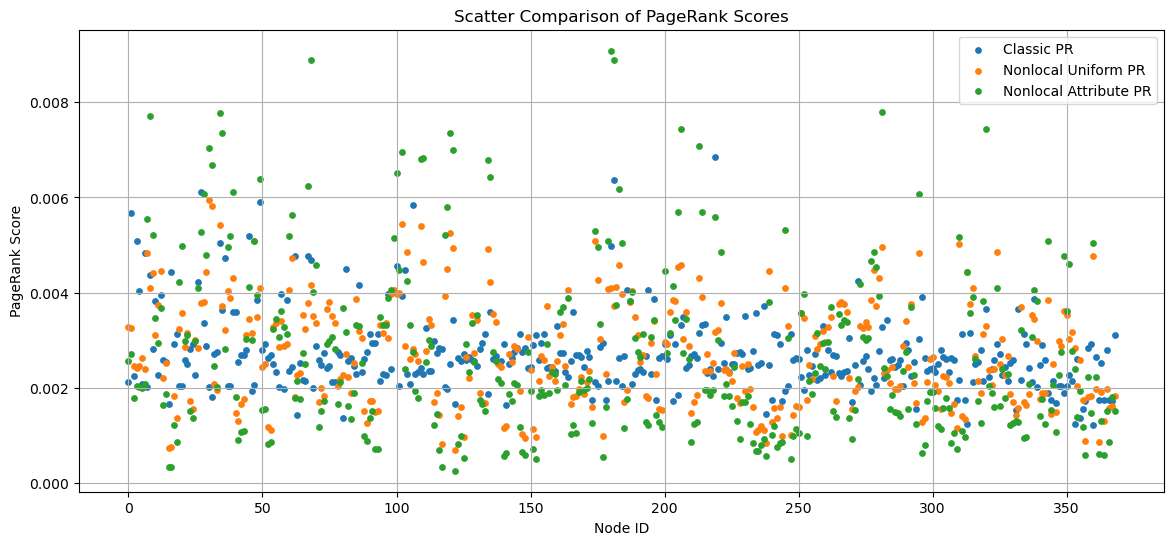

In [29]:
plt.figure(figsize=(14,6))

plt.scatter(df["node"], df["Classic"], label="Classic PR", s=15)
plt.scatter(df["node"], df["Nonlocal_Uniform"], label="Nonlocal Uniform PR", s=15)
plt.scatter(df["node"], df["Nonlocal_Attr"], label="Nonlocal Attribute PR", s=15)

plt.title("Scatter Comparison of PageRank Scores")
plt.xlabel("Node ID")
plt.ylabel("PageRank Score")
plt.legend()
plt.grid(True)
plt.show()

In [30]:
pr_nonlocal_attr.sum()

np.float64(1.0000000000000007)

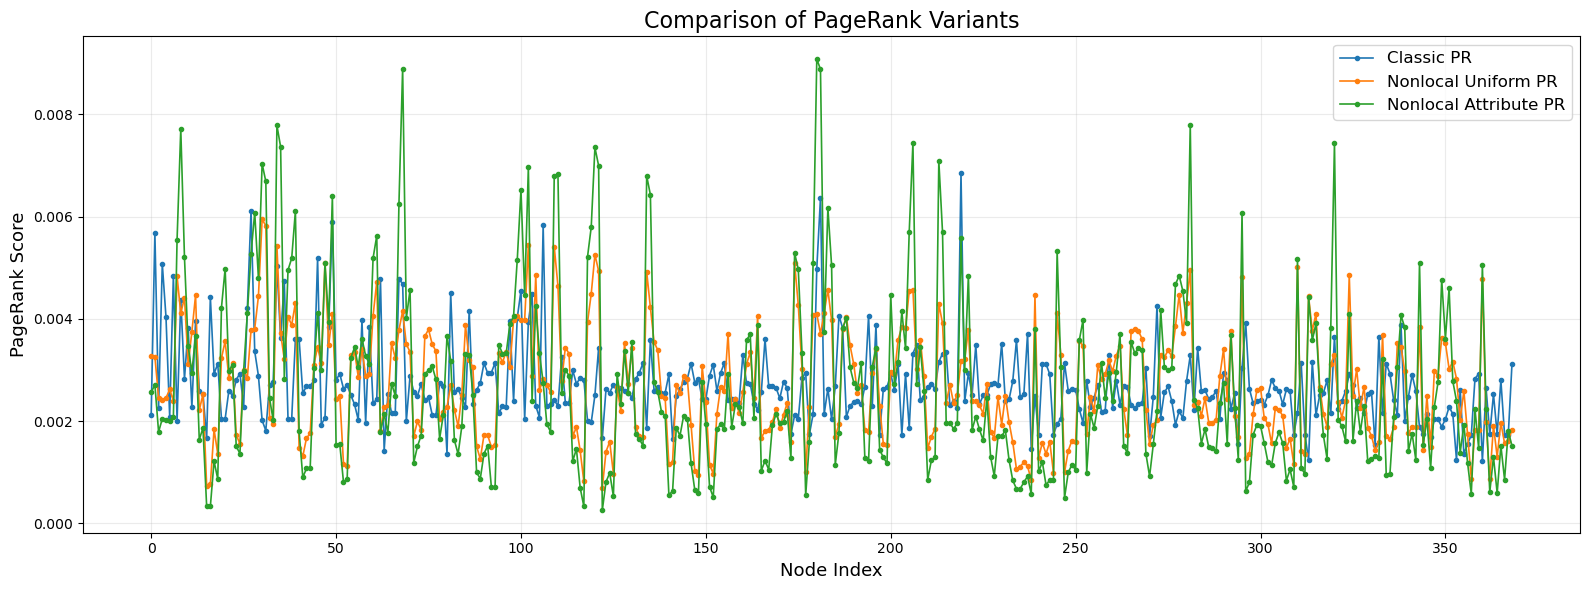

In [31]:
df = df.sort_values("node")

plt.figure(figsize=(16, 6))

plt.plot(df["node"], df["Classic"], 
         label="Classic PR", 
         marker='o', markersize=3, linewidth=1.2)

plt.plot(df["node"], df["Nonlocal_Uniform"], 
         label="Nonlocal Uniform PR", 
         marker='o', markersize=3, linewidth=1.2)

plt.plot(df["node"], df["Nonlocal_Attr"], 
         label="Nonlocal Attribute PR", 
         marker='o', markersize=3, linewidth=1.2)

plt.xlabel("Node Index", fontsize=13)
plt.ylabel("PageRank Score", fontsize=13)
plt.title("Comparison of PageRank Variants", fontsize=16)

plt.grid(alpha=0.25)
plt.legend(fontsize=12)
plt.tight_layout()

plt.savefig("Comp.png", dpi=300, bbox_inches='tight')
plt.show()

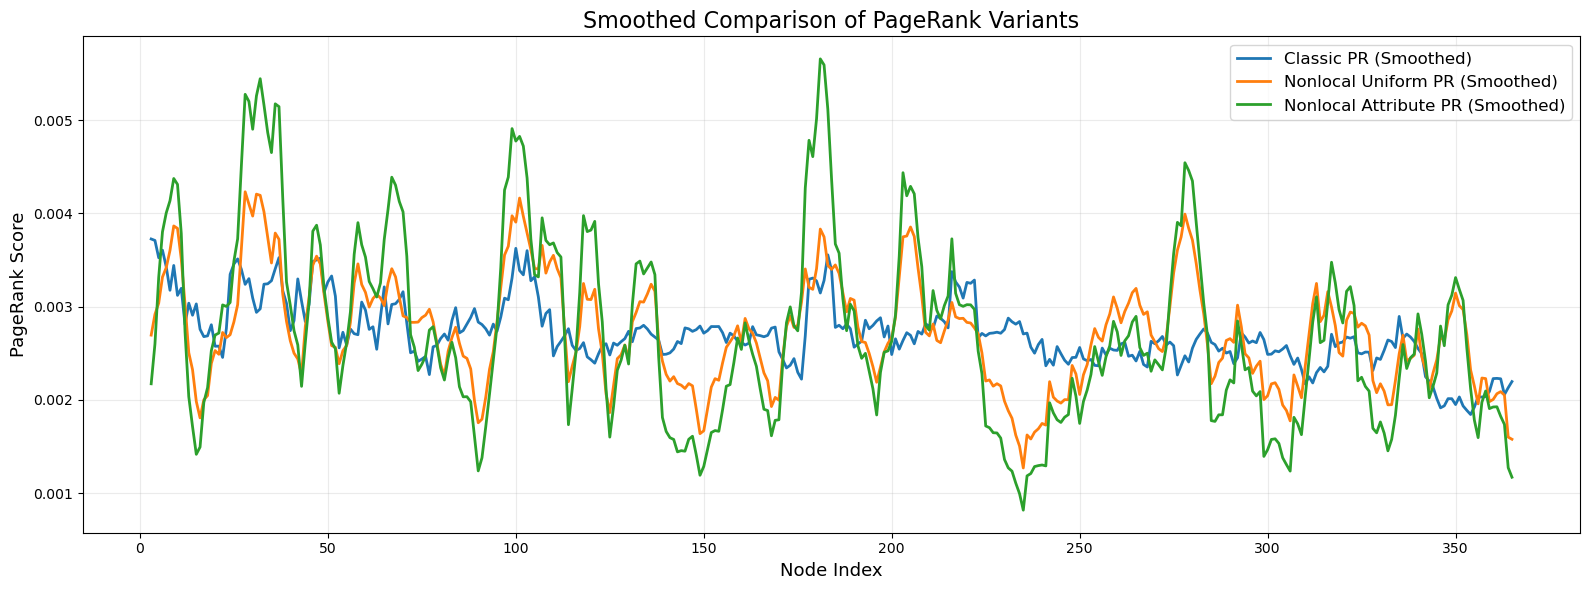

In [32]:
import matplotlib.pyplot as plt
import pandas as pd

df = df.sort_values("node")

# Apply smoothing
window = 7  # try 5, 7, or 11 depending on how smooth you want
df["Classic_s"] = df["Classic"].rolling(window, center=True).mean()
df["NLU_s"] = df["Nonlocal_Uniform"].rolling(window, center=True).mean()
df["NLA_s"] = df["Nonlocal_Attr"].rolling(window, center=True).mean()

plt.figure(figsize=(16, 6))

plt.plot(df["node"], df["Classic_s"], 
         label="Classic PR (Smoothed)", linewidth=2)

plt.plot(df["node"], df["NLU_s"], 
         label="Nonlocal Uniform PR (Smoothed)", linewidth=2)

plt.plot(df["node"], df["NLA_s"], 
         label="Nonlocal Attribute PR (Smoothed)", linewidth=2)

plt.xlabel("Node Index", fontsize=13)
plt.ylabel("PageRank Score", fontsize=13)
plt.title("Smoothed Comparison of PageRank Variants", fontsize=16)

plt.grid(alpha=0.25)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()